# ANALYSIS OF SCORES

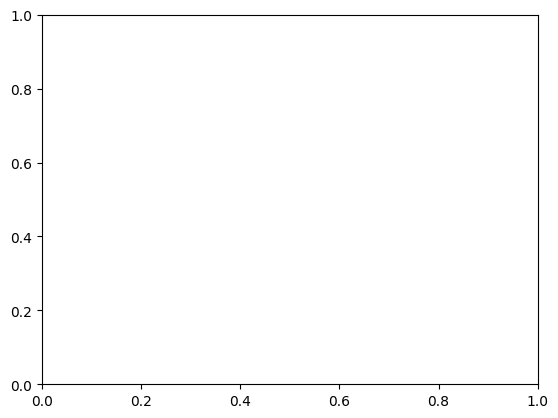

In [1]:
from src.score import Score
from src.trajectory import Trajectory
import os
import src.constants as cn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Timeseries Plots

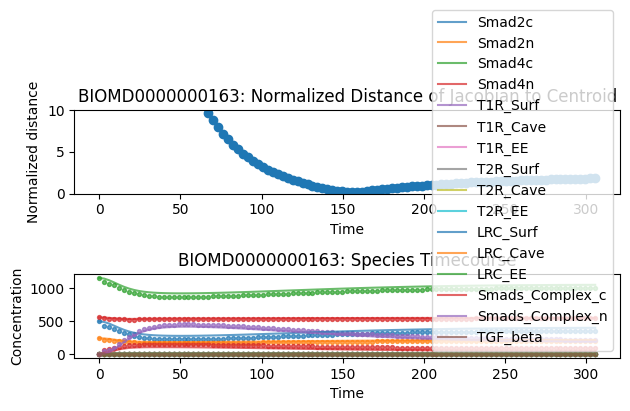

In [2]:
trajectory = Trajectory.makeBiomodel(model_num=163)
_ = trajectory.plot(ylim=[0, 10])

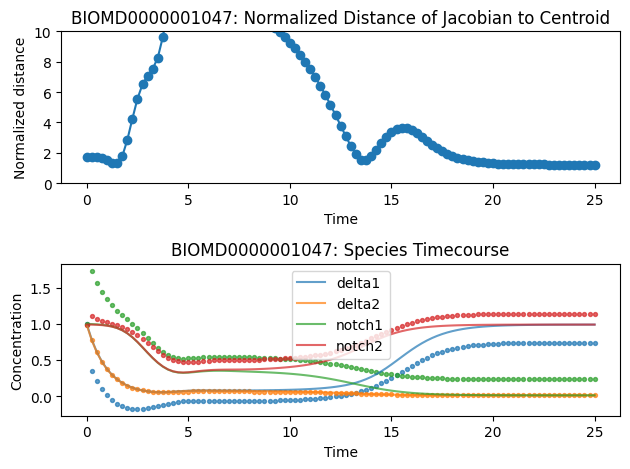

In [3]:
trajectory = Trajectory.makeBiomodel(model_num=1047)
_ = trajectory.plot(ylim=[0, 10])

# Histograms

## Aggregate Data

In [4]:
ffiles = [f for f in os.listdir(cn.DATA_DIR) if "linear_predictor_score" in f]
dfs = []
for ffile in ffiles:
    df = pd.read_csv(os.path.join(cn.DATA_DIR, ffile))
    dfs.append(df)
merged_df = pd.concat(dfs)
ALL_DF = merged_df.reset_index()
ALL_PATH = "all_data.csv"
ALL_DF.to_csv(ALL_PATH)

Text(0.5, 1.0, 'RAE 95th Percentile for 510 Models')

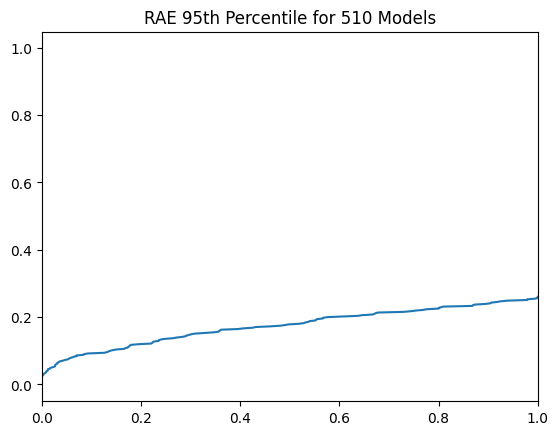

In [6]:
MODEL_DF = ALL_DF[ALL_DF["aggregation_type"] == "model"]
p95_arr = np.sort(MODEL_DF["p95"].values)
count = len(p95_arr)
_, ax = plt.subplots()
ax.plot(p95_arr, np.array(range(count))/count)
ax.set_xlim(0, 1)
ax.set_title(f"RAE 95th Percentile for {len(MODEL_DF)} Models")

Text(0.5, 1.0, 'RAE 95th Percentile for 6350 Species')

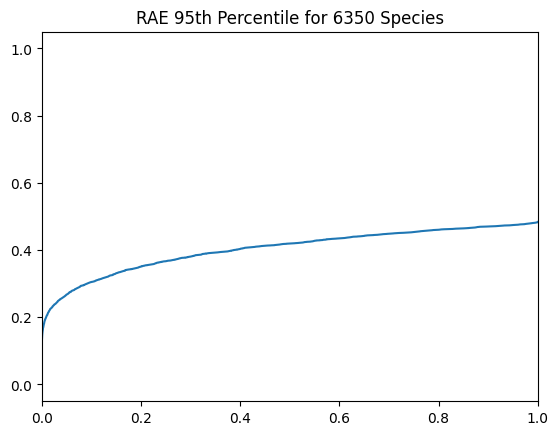

In [7]:
SPECIES_DF = ALL_DF[ALL_DF["aggregation_type"] != "model"]
p95_arr = np.sort(SPECIES_DF["p95"].values)
count = len(p95_arr)
_, ax = plt.subplots()
ax.plot(p95_arr, np.array(range(count))/count)
ax.set_xlim(0, 1)
ax.set_title(f"RAE 95th Percentile for {len(SPECIES_DF)} Species")